## Phase 6: Advanced Vision & Imbalance (APTOS 2019)

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.io import read_image
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


### Dataset Setup

In [ ]:
class RetinalFundusDataset(Dataset):
    """
    PyTorch Dataset for the APTOS 2019 Blindness Detection task.
    Loads retinal fundus images from a CSV manifest and applies optional transforms.
    Labels correspond to diabetic retinopathy severity grades (0-4).
    """

    def __init__(self, csv_path, img_dir, transform=None):
        self.transform = transform
        self.img_paths = []
        self.labels = []

        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            full_path = os.path.join(img_dir, row['id_code'] + '.png')
            if os.path.exists(full_path):
                self.img_paths.append(full_path)
                self.labels.append(row['diagnosis'])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Read image, keep only 3 channels, normalise to [0, 1]
        img = read_image(self.img_paths[idx])[:3].float() / 255.0
        if img.shape[0] == 1:    
            img = img.repeat(3, 1, 1)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [3]:
DATA_DIR = '/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/Assignment_2/Datasets'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'aptos2019-blindness-detection/train_images')
TRAIN_CSV     = os.path.join(DATA_DIR, 'aptos2019-blindness-detection/train.csv')

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

retinal_dataset = RetinalFundusDataset(TRAIN_CSV, TRAIN_IMG_DIR, transform=img_transform)
print(f"Total samples: {len(retinal_dataset)}")

Total samples: 3662


### Helper Functions

In [4]:
def count_params(model):
    """Return total and trainable parameter counts for a model."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def run_training(train_dl, val_dl, model, criterion, optimizer,
                 num_epochs=10, patience=5):
    """
    Standard training loop with early stopping.
    Returns the per-epoch validation loss history.
    """
    best_val  = float('inf')
    no_improv = 0
    best_state = None
    val_history = []

    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()
        train_loss = 0.0
        for X, y in train_dl:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_dl)

        # --- Validation phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model(X), y).item()
        val_loss /= len(val_dl)
        val_history.append(val_loss)

        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}  |  Val Loss = {val_loss:.4f}")

        if val_loss < best_val:
            best_val   = val_loss
            no_improv  = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improv += 1
            if no_improv >= patience:
                print(f"Early stopping triggered at epoch {epoch}. Best val loss: {best_val:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return val_history


def evaluate_model(test_dl, model, criterion):
    """
    Run inference on the test set.
    Returns raw logit list and true label list.
    """
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for X, y in test_dl:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item()
            all_logits.extend(logits.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    total_loss /= len(test_dl)
    print(f"Test Loss ({criterion.__class__.__name__}): {total_loss:.4f}")
    return all_logits, all_labels

#### **Problem 6.16**: Transfer Learning & Freezing

Trainable parameters : 2,565
Frozen    parameters : 11,176,512
Total     parameters : 11,179,077

Starting transfer-learning training (head only)...
Epoch 0: Train Loss = 1.0470  |  Val Loss = 0.7615
Epoch 1: Train Loss = 0.7730  |  Val Loss = 0.6709
Epoch 2: Train Loss = 0.7189  |  Val Loss = 0.6180
Epoch 3: Train Loss = 0.6526  |  Val Loss = 0.6070
Epoch 4: Train Loss = 0.6406  |  Val Loss = 0.5833
Epoch 5: Train Loss = 0.6239  |  Val Loss = 0.5771
Epoch 6: Train Loss = 0.5898  |  Val Loss = 0.5583
Epoch 7: Train Loss = 0.5825  |  Val Loss = 0.5550
Epoch 8: Train Loss = 0.5690  |  Val Loss = 0.5566
Epoch 9: Train Loss = 0.5662  |  Val Loss = 0.5540


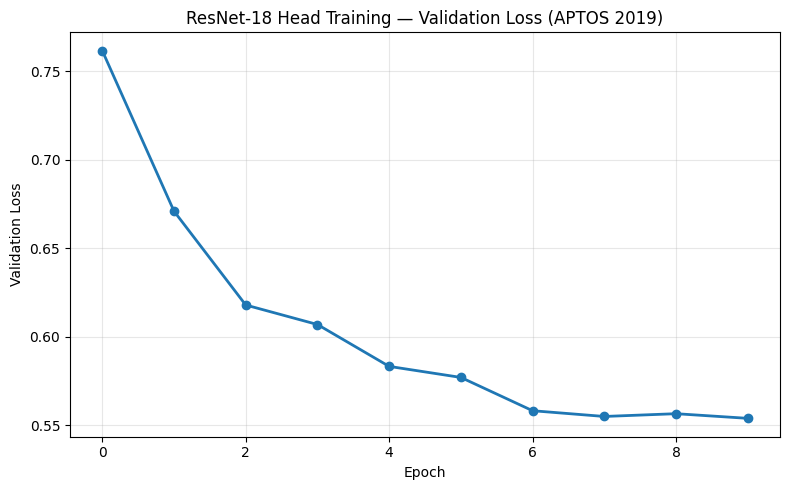

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in backbone.parameters():
    param.requires_grad = False

num_features = backbone.fc.in_features      # 512 for ResNet-18
backbone.fc  = nn.Linear(num_features, 5)   # 5 severity grades
backbone     = backbone.to(device)

total_params, trainable_params = count_params(backbone)
frozen_params = total_params - trainable_params
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen    parameters : {frozen_params:,}")
print(f"Total     parameters : {total_params:,}")

N   = len(retinal_dataset)
idx = np.random.permutation(N)

train_idx = idx[:int(0.70 * N)]
val_idx   = idx[int(0.70 * N):int(0.85 * N)]
test_idx  = idx[int(0.85 * N):]

train_ds = Subset(retinal_dataset, train_idx)
val_ds   = Subset(retinal_dataset, val_idx)
test_ds  = Subset(retinal_dataset, test_idx)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False)

ce_criterion  = nn.CrossEntropyLoss()
head_optimizer = torch.optim.Adam(backbone.parameters(), lr=1e-3)

print("\nStarting transfer-learning training (head only)...")
val_loss_curve = run_training(
    train_dl, val_dl, backbone, ce_criterion, head_optimizer,
    num_epochs=10, patience=5
)

plt.figure(figsize=(8, 5))
plt.plot(range(len(val_loss_curve)), val_loss_curve, marker='o', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("ResNet-18 Head Training — Validation Loss (APTOS 2019)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
np.random.seed(40)
torch.manual_seed(40)

# Evaluate on the held-out test set
logits_ce, true_labels_ce = evaluate_model(test_dl, backbone, ce_criterion)

logit_tensor = torch.tensor(logits_ce)
label_tensor = torch.tensor(true_labels_ce)

pred_probs  = torch.softmax(logit_tensor, dim=1)
pred_labels = torch.argmax(pred_probs, dim=1)

acc = (pred_labels == label_tensor).float().mean().item()
print(f"Test Accuracy : {acc * 100:.2f}%")
print(f"Cohen's QWK   : {cohen_kappa_score(label_tensor.numpy(), pred_labels.numpy(), weights='quadratic'):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(label_tensor.numpy(), pred_labels.numpy()))

Test Loss (CrossEntropyLoss): 0.5753
Test Accuracy : 77.45%
Cohen's QWK   : 0.7947
Confusion Matrix:
[[275   4   3   0   0]
 [  5  23  30   0   1]
 [  4   7 122   2   1]
 [  2   1  23   2   3]
 [  1   3  33   1   4]]


#### **Problem 6.17**: Ordinal Imbalance & Focal Loss

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.

    FL(p_t) = -(1 - p_t)^gamma * log(p_t)

    Args:
        gamma (float): Focusing parameter. gamma=0 reduces to standard CE.
    """

    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Per-sample cross-entropy
        ce_per_sample = nn.CrossEntropyLoss(reduction='none')(logits, targets)
        # Probability of the ground-truth class
        p_t = torch.exp(-ce_per_sample)
        # Down-weight easy examples
        focal_weight = (1.0 - p_t) ** self.gamma
        return (focal_weight * ce_per_sample).mean()

In [ ]:
np.random.seed(42)
torch.manual_seed(42)


backbone_fl = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in backbone_fl.parameters():
    param.requires_grad = False
backbone_fl.fc = nn.Linear(backbone_fl.fc.in_features, 5)
backbone_fl    = backbone_fl.to(device)

total_p, train_p = count_params(backbone_fl)
print(f"Trainable parameters : {train_p:,}")
print(f"Total     parameters : {total_p:,}")


N   = len(retinal_dataset)
idx = np.random.permutation(N)
train_idx = idx[:int(0.70 * N)]
val_idx   = idx[int(0.70 * N):int(0.85 * N)]
test_idx  = idx[int(0.85 * N):]

train_ds_fl = Subset(retinal_dataset, train_idx)
val_ds_fl   = Subset(retinal_dataset, val_idx)
test_ds_fl  = Subset(retinal_dataset, test_idx)

train_dl_fl = DataLoader(train_ds_fl, batch_size=32, shuffle=True)
val_dl_fl   = DataLoader(val_ds_fl,   batch_size=32, shuffle=False)
test_dl_fl  = DataLoader(test_ds_fl,  batch_size=32, shuffle=False)

# Focal loss instead of CE
focal_criterion = FocalLoss(gamma=2.0)
fl_optimizer    = torch.optim.Adam(backbone_fl.parameters(), lr=1e-3)

print("\nStarting training with Focal Loss...")
fl_val_curve = run_training(
    train_dl_fl, val_dl_fl, backbone_fl, focal_criterion, fl_optimizer,
    num_epochs=10, patience=5
)

Trainable parameters : 2,565
Total     parameters : 11,179,077

Starting training with Focal Loss...
Epoch 0: Train Loss = 0.6073  |  Val Loss = 0.3972
Epoch 1: Train Loss = 0.4113  |  Val Loss = 0.3460
Epoch 2: Train Loss = 0.3746  |  Val Loss = 0.3091
Epoch 3: Train Loss = 0.3247  |  Val Loss = 0.3165
Epoch 4: Train Loss = 0.3187  |  Val Loss = 0.2914
Epoch 5: Train Loss = 0.3097  |  Val Loss = 0.3113
Epoch 6: Train Loss = 0.2896  |  Val Loss = 0.2849
Epoch 7: Train Loss = 0.2829  |  Val Loss = 0.2851
Epoch 8: Train Loss = 0.2726  |  Val Loss = 0.2878
Epoch 9: Train Loss = 0.2704  |  Val Loss = 0.2908


In [11]:
np.random.seed(30)
torch.manual_seed(30)

# Evaluate with Focal Loss model
logits_fl, true_labels_fl = evaluate_model(test_dl_fl, backbone_fl, focal_criterion)

logit_tensor_fl = torch.tensor(logits_fl)
label_tensor_fl = torch.tensor(true_labels_fl)

pred_probs_fl  = torch.softmax(logit_tensor_fl, dim=1)
pred_labels_fl = torch.argmax(pred_probs_fl, dim=1)

acc_fl = (pred_labels_fl == label_tensor_fl).float().mean().item()
qwk_fl = cohen_kappa_score(label_tensor_fl.numpy(), pred_labels_fl.numpy(), weights='quadratic')

print(f"Test Accuracy : {acc_fl * 100:.2f}%")
print(f"Cohen's QWK   : {qwk_fl:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(label_tensor_fl.numpy(), pred_labels_fl.numpy()))

Test Loss (FocalLoss): 0.3159
Test Accuracy : 77.45%
Cohen's QWK   : 0.8138
Confusion Matrix:
[[275   3   4   0   0]
 [  5  14  39   0   1]
 [  6   1 126   1   2]
 [  2   0  24   1   4]
 [  1   1  30   0  10]]
